# Typed Annotations
- explicitly define datatypes of certain kinds of variables
- Reason
    - for the below dictionary example, the first one doesn't have a specific datatype of key and value, hence works with any key/value datatype.
    - Pros:
        - easy to implement
        - efficient data retrieval using unique keys
    - Cons
        - data of a particular structure cannot be checked
        - even if a dictionary of a certain key-datatype:value-datatype needs to be used, whether each key-value pair obeys this structure cannot be checked.
        - also, the key-value structure could also be anything
            - say we want to build a dictionary where key: int, value: list[float]
            - a normal dict cannot ensure that
- in order to ensure the correct structure and correct key-value datatypes are followed: Typed Annotations are used
    - for dictionary, this would be a `typing.TypedDict`
    - Python itself will not raise an exception at runtime. 
    - The type checking is purely static and done by tools like mypy or Pyright, not by the Python interpreter. 
    - So, your code will run without error unless you use a static type checker that flags the mismatch
- to enable static type checking in vscode using already installed pylance
    - `Cmd+Shift+P`: open `settings.json` (that of the user will do)
    - type in this: `"python.analysis.typeCheckingMode": "basic"`
        - use `"strict"` instead of `"basic"` for more stricter type checking
    

In [7]:
normal_dict = {1.0: "a", 2: 2.2}
print(normal_dict)

{1.0: 'a', 2: 2.2}


In [13]:
from typing import TypedDict, Optional, Any

class Movie(TypedDict):
    name: str
    year: int

movie: Movie = {'name': 'Blade Runner',
                'year': 1982}
print(movie)

movie['director'] = 'Ridley Scott'  # Pylance/any other static type checker highlights: Error: invalid key 'director'
movie['year'] = '1982'  # Pylance/any other static type checker highlights: Error: invalid value type ("int" expected)

def msg(name: Optional[str]) -> None:
    """
    msg can only be of type None or str
    any other static type will be flagged by type checker itself
    dynamic types can only be known at runtime
    """
    if name is None:
        print(f"Hey there!")
    else:
        print(f"Hey there, {name}")

msg(name = "Aklkk")
msg(name = None)
msg(name = [132])
msg(name = 1234321)
msg(name = 1.222)


def any_example(x: Any):
    print(x)

any_example(None)
any_example("")
any_example({1: 3})
any_example(1.22)

{'name': 'Blade Runner', 'year': 1982}
Hey there, Aklkk
Hey there!
Hey there, [132]
Hey there, 1234321
Hey there, 1.222
None

{1: 3}
1.22


# LangGraph Terminology
- State: entire data of the app.
- Node: unit of work/computation performed using State as the input.
- Graph: execution flow of nodes
- tools: functions used within a Node to perform its internal computation.
    - **doesn't mean** that what a Node does is simply call tools.
- ToolNode: a node whose job is to simply call a tool using the current State.
- StateGraph: 

In [14]:
!pip install langgraph

  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached jsonpointer-3.0.0-py2.py3-none-any.whl.metadata (2.3 kB)
Using cached jsonpatch-1.33-py2.py3-none-any.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.5/633.5 kB 15.2 MB/s eta 0:00:00
Using cached jsonpointer-3.0.0-py2.py3-none-any.whl (7.6 kB)
  Attempting uninstall: xxhash
    Found existing installation: xxhash 3.4.1
    Uninstalling xxhash-3.4.1:
      Successfully uninstalled xxhash-3.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [langgraph]14 [langgraph-checkpoint]


In [42]:
!pip install langchain-ollama

# Chatbot Agent - Toolless

In [1]:
from typing import TypedDict, Optional, List, Union

from IPython.display import Image, display

from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.state import StateGraph
from langgraph.constants import START, END

from langchain_ollama import ChatOllama

In [9]:
class AgentState(TypedDict):
    history: List[Union[HumanMessage, AIMessage]]
    system: Optional[str]
    is_chat_on: bool

In [ ]:
llm = ChatOllama(
    model='llama3.2'
)

def chat(state: AgentState) -> AgentState:
    """
    Chats with the llm, providing the conversational history as context
    """
    user_input: str = input()
    if user_input == "exit":
        state['is_chat_on'] = False
        return state
    else:
        user_input = user_input.strip()
        state['is_chat_on'] = True
        if user_input != "":
            state['history'].append(HumanMessage(user_input))
            llm_resp = llm.invoke(state['history']).content
            state['history'].append(AIMessage(llm_resp))
        return state

def end_chat(state: AgentState):
    """
    checks the is_chat_on and decides whether to:
    - visit the chat node
    - exits the graph

    this will be used in the conditional 
    """
    if state['is_chat_on']:
        return "continue_chat"
    else:
        return "end_chat"

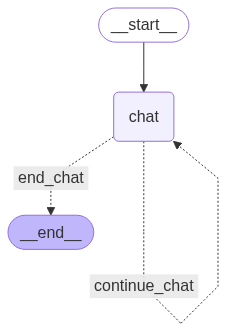

In [14]:
def create_graph():
    pass

chatbot: StateGraph = StateGraph(state_schema=AgentState)

chatbot.add_node(node="chat", action=chat)

chatbot.add_edge(START, "chat")
chatbot.add_conditional_edges(
    "chat",
    end_chat,
    {
        "end_chat": END,
        "continue_chat": "chat"
    }
)

chatbot_app = chatbot.compile()
display(Image(chatbot_app.get_graph().draw_mermaid_png()))

In [15]:
chatbot_app.invoke({
    'history': [], 
    'system': 'You are a helpful AI Assistant who will answer any queries the user has.',
    'is_chat_on': True
})

{'history': [HumanMessage(content='capital of libya', additional_kwargs={}, response_metadata={}),
  AIMessage(content='The capital of Libya is Tripoli.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='full form of SARC', additional_kwargs={}, response_metadata={}),
  AIMessage(content='SARC is an acronym that can stand for several things, but some common full forms are:\n\n1. Self-Accidental Respiratory Cardiac (in the context of medical conditions)\n2. Student Activities and Resources Center\n3. South Asian Regional Center (in the context of cultural or educational institutions)\n\nWithout more context, it\'s difficult to determine which one is correct. If you can provide more information about where you encountered the term "SARC", I may be able to give a more specific answer.', additional_kwargs={}, response_metadata={})],
 'system': 'You are a helpful AI Assistant who will answer any queries the user has.',
 'is_chat_on': False}

# Chatbot Agent - Tool-full

In [1]:
from typing import TypedDict, Annotated, Sequence, Optional, List, Union

from IPython.display import Image, display

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, SystemMessage
from langchain_core.tools import tool

from langchain_ollama import ChatOllama

- tool functions have the freedom of accepting any arguments they need

In [2]:
@tool
def add(a: int, b: int) -> float:
    """
    Given two numbers, add them and return their sum
    """
    return a+b

@tool
def valadrium_add(a: int, b: int) -> float:
    """
    Given two numbers, this returns their valadrium sum.
    This is the sum of quotients of the division of the first number by the second
    , and the second number by the first.
    """
    return (a // b if b != 0 else a) + (b // a if a != 0 else b)

@tool
def talberron_divide(a: int, b: int) -> float:
    """
    Given two numbers, this returns their talberron divide.
    This is the division of the sum of their squares by their sum.
    """
    return (a ** 2 + b ** 2) / (a+b)

llm = ChatOllama(
    model='llama3.2'
).bind_tools([add, valadrium_add, talberron_divide])

Test whether the Ollama ChatModel is calling the apt tool

In [3]:
resp_1 = llm.invoke(input = "Hi LLM, this is Pythagorus. What will be the addition of the numbers 6 and 8?")
resp_2 = llm.invoke(input = "Hi LLM, this is a human. Tell me the valadrium sum of the numbers 6 and 8?")
resp_3 = llm.invoke(input = "Hi LLM, this is a human. Tell me the talberron division of the numbers 6 and 8?")

print(f"Response using tools {resp_1.tool_calls} is: {resp_1.content}\n")
print(f"Response using tools {resp_2.tool_calls} is: {resp_2.content}\n")
print(f"Response using tools {resp_3.tool_calls} is: {resp_3.content}\n")

Response using tools [{'name': 'add', 'args': {'a': '6', 'b': '8'}, 'id': 'fe024fa5-49ca-4098-873f-e067f7d7cd25', 'type': 'tool_call'}] is: 

Response using tools [{'name': 'valadrium_add', 'args': {'a': '6', 'b': '8'}, 'id': '338f1bc1-3a0c-4c2a-944d-cd33f55f9f8e', 'type': 'tool_call'}] is: 

Response using tools [{'name': 'talberron_divide', 'args': {'a': '6', 'b': '8'}, 'id': 'd547d2b1-873c-491f-bbd3-4e9e436d4e2d', 'type': 'tool_call'}] is: 



In [4]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    is_chat_on: bool

# a node that has access to the tool, and is reserved for that particular
# tool calling, will be declared as a ToolNode
@tool
def end_chat():
    """
    Function to end the chat session with the LLM, as per user input.
    If the user input hints at ending the session, then end the session.
    """
    pass

def enter_message(state: AgentState) -> AgentState:
    """
    Wait for the user to enter a message and take decision accordingly
    """
    user_input: str = input().strip()
    # if user_input != "":
    #     pass
    # return state
    if user_input == "exit":
        state['is_chat_on'] = False
        return state
    else:
        user_input = user_input.strip()
        state['is_chat_on'] = True
        if user_input != "":
            llm_resp = llm.invoke(
                state['messages'] + [HumanMessage(user_input)]
            ).content
            state['messages'] = llm_resp
        return state

def should_continue(state: AgentState):
    """
    checks the is_chat_on and decides whether to:
    - visit the chat node
    - exits the graph

    this will be used in the conditional 
    """
    if state['is_chat_on']:
        return "continue_chat"
    else:
        return "end_chat"

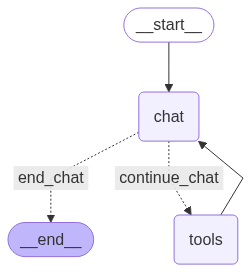

In [8]:
graph = StateGraph(AgentState)
graph.add_node("chat", enter_message)

tool_node = ToolNode(tools=[add, valadrium_add, talberron_divide])
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat")
graph.add_conditional_edges(
    "chat",
    should_continue,
    {
        "continue_chat": "tools",
        "end_chat": END
    }
)
graph.add_edge("tools", "chat")

graph_app = graph.compile()
graph_img = graph_app.get_graph().draw_mermaid_png()
display(Image(graph_img))

In [10]:
graph_app.invoke({
    'history': [],
    'is_chat_on': True
})

ValueError: No AIMessage found in input